In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.utils import resample



# Limpieza y Normalización

In [2]:
df_raw = pd.read_excel("NPS-Mexico-2026-v1.xlsx")


# Nombres columnas
RENAME = {
    df_raw.columns[0]:  "timestamp",
    df_raw.columns[1]:  "banco",
    df_raw.columns[2]:  "activo_3m",
    df_raw.columns[3]:  "antiguedad",
    df_raw.columns[4]:  "productos",
    df_raw.columns[5]:  "canales_usados",
    df_raw.columns[6]:  "canal_principal",
    df_raw.columns[7]:  "facilidad_resolucion",        
    df_raw.columns[8]:  "resolucion_primer_contacto",
    df_raw.columns[9]:  "rapidez",                     
    df_raw.columns[10]: "transparencia",
    df_raw.columns[11]: "facilidad_digital",
    df_raw.columns[12]: "estabilidad_digital",
    df_raw.columns[13]: "confianza",
    df_raw.columns[14]: "atencion_humana",
    df_raw.columns[15]: "satisfaccion_general",        
    df_raw.columns[16]: "nps_score",                   
    df_raw.columns[17]: "razon_nps",
    df_raw.columns[18]: "edad",
    df_raw.columns[19]: "estado",
    df_raw.columns[20]: "escolaridad",
    df_raw.columns[21]: "ocupacion",
}
df = df_raw.rename(columns=RENAME).copy()

# Nombres Estandar
df["banco"] = df["banco"].str.strip()
BANCO_MAP = {
    "NU": "Nu", "Banco NU": "Nu", "Banco Azteca": "Banco Azteca",
    "Inbursa ": "Inbursa", "Invex banco ": "Invex", "Invex Banco ": "Invex"
}
df["banco"] = df["banco"].replace(BANCO_MAP)

# Etiquetas NPS
def clasificar_nps(score):
    if score <= 6:   return 0 # Detractor
    elif score <= 8: return 1 # Neutro
    else:            return 2 # Promotor

df["nps_label"] = df["nps_score"].apply(clasificar_nps)
nps_counts = df["nps_label"].value_counts()


# Mapeos ordinales 
ORDINAL_5 = {
    "Muy buena": 5, "Buena": 4, "Regular": 3, "Mala": 2, "Muy mala": 1, "No aplica": np.nan
}
RESOLUCION_MAP = {"Si": 1, "No": 0, "No aplica (no tuvo interacción reciente)": np.nan}

COLS_LIKERT = ["rapidez", "transparencia", "facilidad_digital",
               "estabilidad_digital", "confianza", "atencion_humana"]

for col in COLS_LIKERT:
    df[col] = df[col].map(ORDINAL_5)

df["resolucion_primer_contacto"] = df["resolucion_primer_contacto"].map(RESOLUCION_MAP)

# Antigüedad → numérico ordinal
ANTIGUEDAD_MAP = {
    "Menos de 6 meses": 1, "6-12 meses": 2, "1–3 años": 3,
    "3–5 años": 4, "Más de 5 años": 5, "No lo sabe / Prefiere no responder": np.nan
}
df["antiguedad_num"] = df["antiguedad"].map(ANTIGUEDAD_MAP)

# Canal principal → digital vs presencial
CANAL_DIGITAL = ["App móvil", "Sitio web (banca en línea)"]
df["canal_digital"] = df["canal_principal"].apply(
    lambda x: 1 if any(d in str(x) for d in CANAL_DIGITAL) else 0
)

# Número de productos utilizados
df["n_productos"] = df["productos"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) and x != "No aplica / No lo recuerda" else 0
)

# Número de canales usados
df["n_canales"] = df["canales_usados"].apply(
    lambda x: len(str(x).split(",")) if pd.notna(x) else 1
)

# Análisis exploratorio de datos

In [3]:
# Tamaño del dataset
print("Número de registros:", df.shape[0])
print("Número de columnas:", df.shape[1])

# Vista general
df.head()

Número de registros: 193
Número de columnas: 27


,timestamp,banco,activo_3m,antiguedad,productos,canales_usados,canal_principal,facilidad_resolucion,resolucion_primer_contacto,rapidez,...,razon_nps,edad,estado,escolaridad,ocupacion,nps_label,antiguedad_num,canal_digital,n_productos,n_canales
0,2026-03-11 16:55:42.769,Banorte,Si,3–5 años,"Cuenta de débito / nómina, Tarjeta de débito, ...","App móvil, Cajero automático, Teléfono (call c...",App móvil,2,0.0,4.0,...,"Siempre que tuve problemas, demoré más de 2 ho...",35–49,Ciudad de México,Posgrado - Doctorado,Estudiante / Empleado(a),1,4.0,1,5,4
1,2026-03-11 17:08:03.727,Citibanamex,Si,6-12 meses,"Cuenta de débito / nómina, Tarjeta de débito, ...","App móvil, Asesor/ejecutivo (presencial o remoto)",App móvil,5,1.0,5.0,...,buena atención en el poco tiempo que estoy con...,35–49,Ciudad de México,Posgrado - Doctorado,Estudiante / Empleado(a),2,2.0,1,5,2
2,2026-03-11 17:41:06.019,HSBC,Si,6-12 meses,"Tarjeta de débito, Inversión / ahorro programa...","App móvil, Sitio web (banca en línea), Sucursa...",App móvil,2,0.0,4.0,...,"HSBC es un buen banco, pero a veces los términ...",18–24,Ciudad de México,Preparatoria,Estudiante / Empleado(a),1,2.0,1,5,5
3,2026-03-11 17:52:28.810,BBVA,No,1–3 años,Tarjeta de débito,App móvil,App móvil,3,1.0,3.0,...,NaN,18–24,Ciudad de México,Preparatoria,Estudiante / Empleado(a),2,3.0,1,1,1
4,2026-03-11 17:56:12.855,BBVA,Si,Más de 5 años,"Cuenta de débito / nómina, Cuenta de ahorro, T...","App móvil, Sitio web (banca en línea), Sucursa...",App móvil,5,1.0,5.0,...,Porque el servicio del banco es muy bueno,50–64,Ciudad de México,Posgrado - Maestría,Estudiante / Empleado(a),2,5.0,1,8,5


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   timestamp                   193 non-null    datetime64[ns]
 1   banco                       193 non-null    object        
 2   activo_3m                   193 non-null    object        
 3   antiguedad                  193 non-null    object        
 4   productos                   193 non-null    object        
 5   canales_usados              193 non-null    object        
 6   canal_principal             193 non-null    object        
 7   facilidad_resolucion        193 non-null    int64         
 8   resolucion_primer_contacto  173 non-null    float64       
 9   rapidez                     171 non-null    float64       
 10  transparencia               170 non-null    float64       
 11  facilidad_digital           171 non-null    float64       

In [5]:
# Valores nulos por columna
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

atencion_humana               28
razon_nps                     24
transparencia                 23
estabilidad_digital           23
rapidez                       22
facilidad_digital             22
confianza                     21
resolucion_primer_contacto    20
antiguedad_num                 3
dtype: int64

In [6]:
# Distribución del NPS numérico
df["nps_score"].describe()

count    193.000000
mean       8.191710
std        2.086548
min        0.000000
25%        8.000000
50%        9.000000
75%       10.000000
max       10.000000
Name: nps_score, dtype: float64

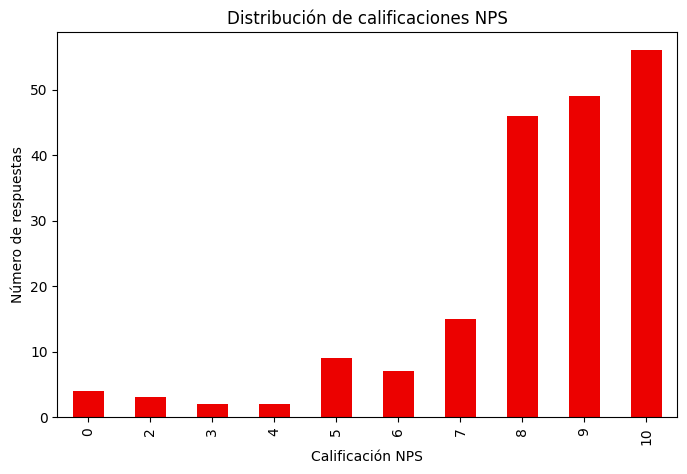

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df["nps_score"].value_counts().sort_index().plot(kind="bar", color="#EC0100")
plt.title("Distribución de calificaciones NPS")
plt.xlabel("Calificación NPS")
plt.ylabel("Número de respuestas")
plt.show()

In [8]:
# Distribución de clases NPS
nps_label_map = {
    0: "Detractor",
    1: "Neutro",
    2: "Promotor"
}

df["nps_categoria"] = df["nps_label"].map(nps_label_map)

df["nps_categoria"].value_counts()

nps_categoria
Promotor     105
Neutro        61
Detractor     27
Name: count, dtype: int64

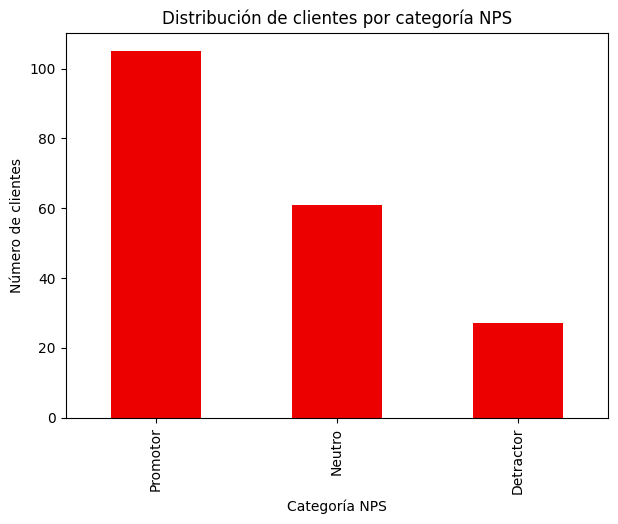

In [9]:
plt.figure(figsize=(7, 5))
df["nps_categoria"].value_counts().plot(kind="bar", color="#EC0100")
plt.title("Distribución de clientes por categoría NPS")
plt.xlabel("Categoría NPS")
plt.ylabel("Número de clientes")
plt.show()

In [10]:
nps_distribution = df["nps_categoria"].value_counts(normalize=True) * 100
nps_distribution.round(2)

nps_categoria
Promotor     54.40
Neutro       31.61
Detractor    13.99
Name: proportion, dtype: float64

La distribución del NPS permite identificar si existe desbalance entre las clases de detractores, neutros y promotores. Este punto es importante porque, si una clase tiene muchos más registros que las demás, los modelos podrían favorecer la predicción de la clase mayoritaria y presentar menor desempeño en las clases menos representadas.

In [11]:
# Distribución por edad
df["edad"].value_counts()

edad
18–24       79
35–49       43
50–64       42
25–34       17
65 o más    12
Name: count, dtype: int64

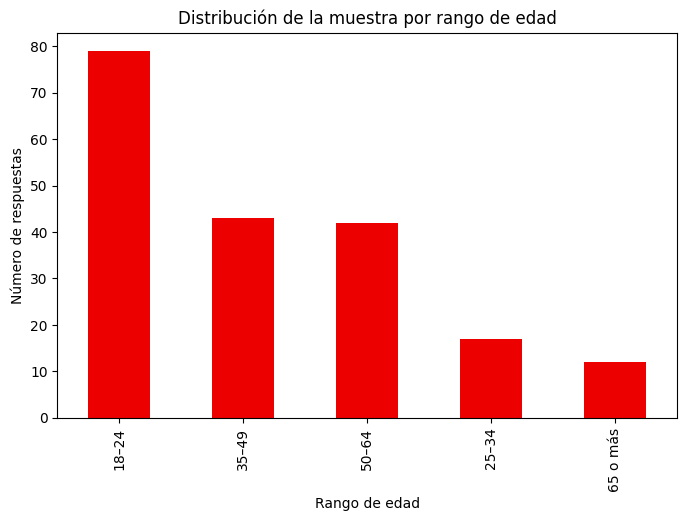

In [12]:
plt.figure(figsize=(8, 5))
df["edad"].value_counts().plot(kind="bar", color="#EC0100")
plt.title("Distribución de la muestra por rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Número de respuestas")
plt.show()

In [13]:
# Tabla cruzada edad vs categoría NPS
edad_nps = pd.crosstab(df["edad"], df["nps_categoria"], normalize="index") * 100
edad_nps.round(2)

nps_categoria,Detractor,Neutro,Promotor
edad,,,
18–24,11.39,36.71,51.90
25–34,17.65,29.41,52.94
35–49,13.95,30.23,55.81
50–64,19.05,26.19,54.76
65 o más,8.33,25.00,66.67


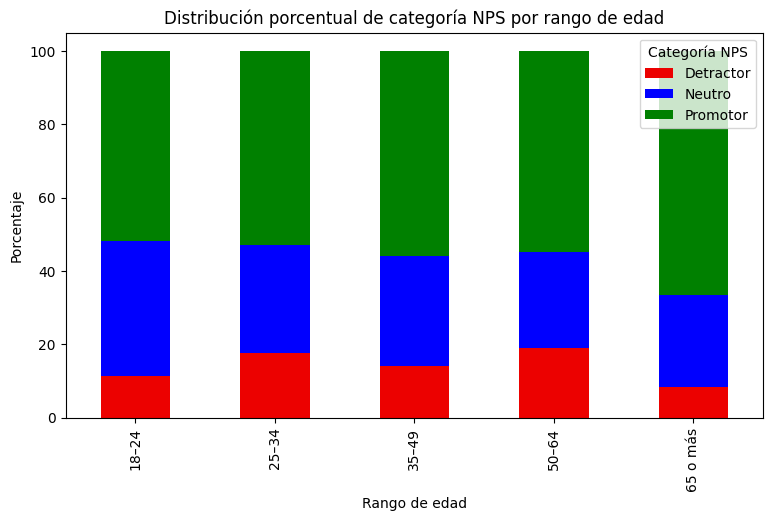

In [14]:
colores_santander = {
    "Detractor": "#EC0100", 
    "Neutro":    "blue", 
    "Promotor":  "green"  
}
edad_nps.plot(kind="bar", stacked=True, figsize=(9, 5), 
              color=[colores_santander[x] for x in edad_nps.columns])
plt.title("Distribución porcentual de categoría NPS por rango de edad")
plt.xlabel("Rango de edad")
plt.ylabel("Porcentaje")
plt.legend(title="Categoría NPS")
plt.show()

El cruce entre rango de edad y categoría NPS permite observar si la percepción del banco varía entre los distintos grupos de edad. También ayuda a identificar posibles sesgos de representación. Si la mayoría de las respuestas se concentra en un grupo de edad, el modelo puede aprender principalmente los patrones de ese segmento y generalizar peor hacia grupos menos representados.

In [15]:
# Distribución por banco
df["banco"].value_counts()

banco
BBVA            85
Banorte         24
Santander       24
Citibanamex     20
HSBC            15
Banco Azteca     8
Scotiabank       7
Nu               3
Inbursa          2
Mercado Pago     2
Invex banco      1
Invex            1
Monex            1
Name: count, dtype: int64

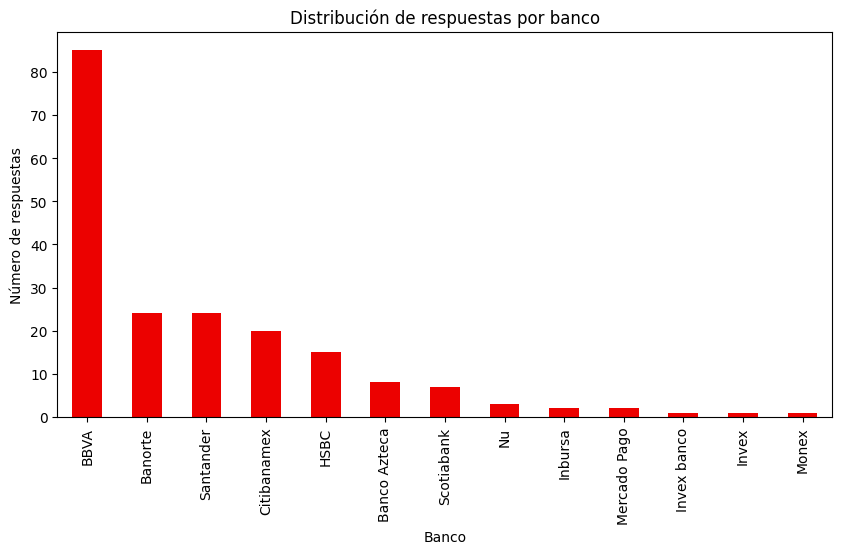

In [16]:
plt.figure(figsize=(10, 5))
df["banco"].value_counts().plot(kind="bar", color="#EC0100")
plt.title("Distribución de respuestas por banco")
plt.xlabel("Banco")
plt.ylabel("Número de respuestas")
plt.show()

In [17]:
# Cruce banco vs NPS
banco_nps = pd.crosstab(df["banco"], df["nps_categoria"], normalize="index") * 100
banco_nps.round(2)

nps_categoria,Detractor,Neutro,Promotor
banco,,,
BBVA,10.59,34.12,55.29
Banco Azteca,12.50,12.50,75.00
Banorte,8.33,37.50,54.17
Citibanamex,20.00,25.00,55.00
HSBC,26.67,20.00,53.33
Inbursa,0.00,0.00,100.00
Invex,0.00,100.00,0.00
Invex banco,0.00,100.00,0.00
Mercado Pago,0.00,50.00,50.00


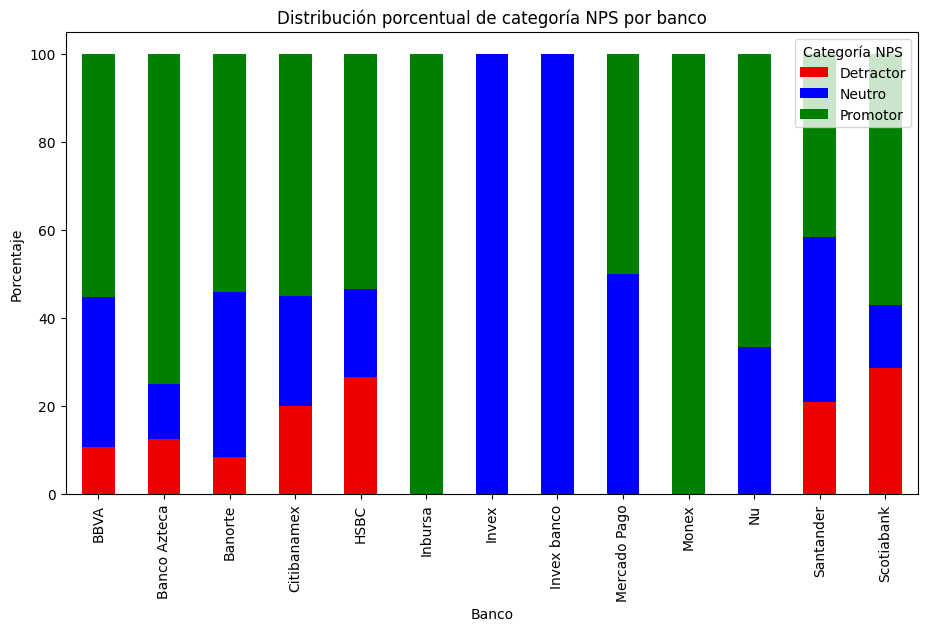

In [18]:
banco_nps.plot(kind="bar", stacked=True, figsize=(11, 6),
               color=[colores_santander[x] for x in banco_nps.columns])
plt.title("Distribución porcentual de categoría NPS por banco")
plt.xlabel("Banco")
plt.ylabel("Porcentaje")
plt.legend(title="Categoría NPS")
plt.show()

El análisis por banco permite observar diferencias en la proporción de detractores, neutros y promotores entre instituciones financieras. Estas diferencias deben interpretarse con cuidado cuando algunos bancos tienen pocos registros, ya que una muestra pequeña puede generar porcentajes poco estables o poco representativos.

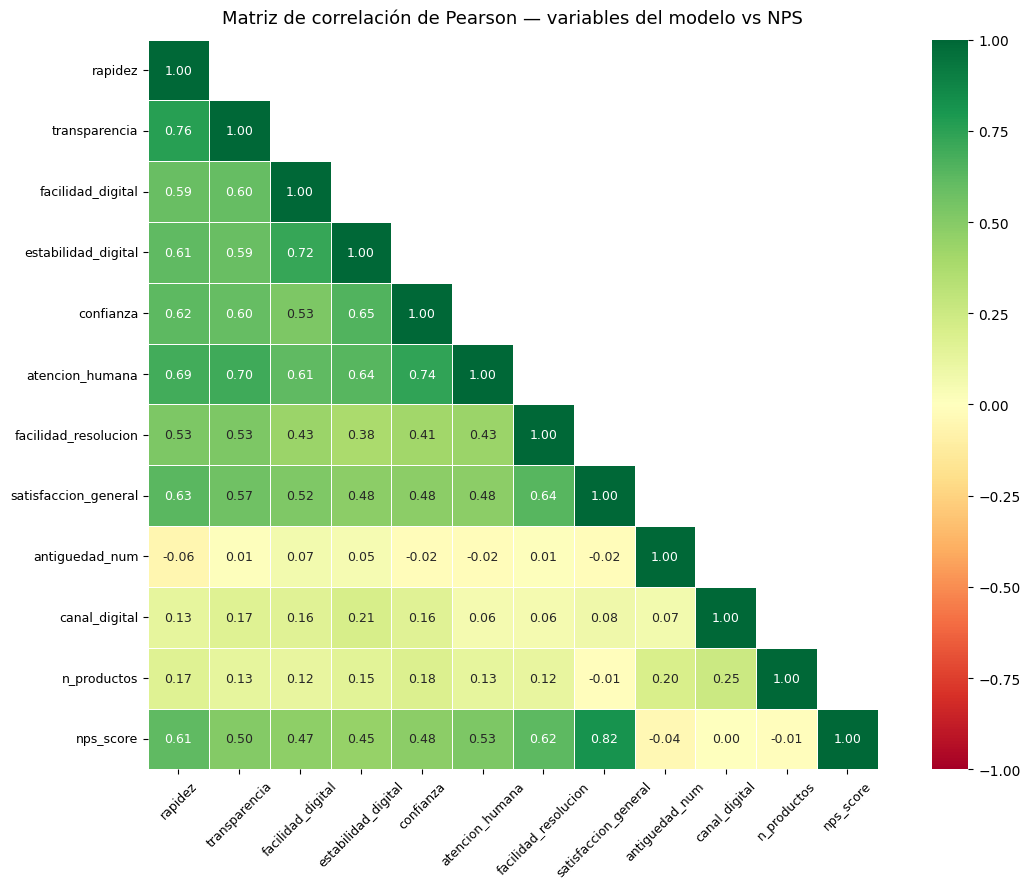

In [19]:
# ── Matriz de correlación ─────────────────────────────────────────────
import seaborn as sns

COLS_CORR = (
    COLS_LIKERT +
    ['facilidad_resolucion', 'satisfaccion_general',
     'antiguedad_num', 'canal_digital', 'n_productos', 'nps_score']
)

# Solo columnas numéricas presentes en df en este punto
cols_disp = [
    c for c in COLS_CORR
    if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
]
corr_matrix = df[cols_disp].corr().round(2)

# Triángulo inferior únicamente (evita redundancia)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    mask=mask,
    ax=ax,
    linewidths=0.5,
    annot_kws={'size': 9},
    square=True
)

ax.set_title(
    'Matriz de correlación de Pearson — variables del modelo vs NPS',
    fontsize=13, pad=12
)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.tight_layout()
plt.show()

## Share y weights

In [20]:
banco_share = df["banco"].value_counts(normalize=True) * 100
print(banco_share.round(1).to_string())

banco
BBVA            44.0
Banorte         12.4
Santander       12.4
Citibanamex     10.4
HSBC             7.8
Banco Azteca     4.1
Scotiabank       3.6
Nu               1.6
Inbursa          1.0
Mercado Pago     1.0
Invex banco      0.5
Invex            0.5
Monex            0.5


In [21]:
SHARE_REAL = {
    "BBVA": 28.0, "Banorte": 15.0, "Citibanamex": 12.0,
    "HSBC": 10.0, "Santander": 12.0, "Scotiabank": 6.0,
    "Banco Azteca": 8.0,
}
weights = {}
for banco, share_real in SHARE_REAL.items():
    share_muestra = banco_share.get(banco, np.nan)
    if pd.notna(share_muestra) and share_muestra > 0:
        weights[banco] = share_real / share_muestra
    else:
        weights[banco] = 1.0

# Para bancos sin share real conocido, peso = 1
df["peso"] = df["banco"].map(weights).fillna(1.0)
df["peso"] = df["peso"] / df["peso"].mean()  # normalizar a media=1

peso_resumen = df.groupby("banco")["peso"].first().sort_values(ascending=False)
print(peso_resumen.round(3).to_string())

banco
Banco Azteca    2.007
Scotiabank      1.720
HSBC            1.338
Banorte         1.254
Citibanamex     1.204
Inbursa         1.040
Invex           1.040
Invex banco     1.040
Mercado Pago    1.040
Monex           1.040
Nu              1.040
Santander       1.003
BBVA            0.661


## Imputación de datos

In [22]:
df_model = df[COLS_LIKERT + ["facilidad_resolucion", "satisfaccion_general",
                              "nps_score", "nps_label", "banco",
                              "antiguedad_num", "canal_digital",
                              "n_productos", "n_canales", "peso"]].copy()

# Imputación por mediana global (no por segmento para evitar data leakage en clustering)
for col in COLS_LIKERT + ["facilidad_resolucion", "resolucion_primer_contacto"]:
    if col in df_model.columns:
        median_val = df_model[col].median()
        missing_count = df_model[col].isna().sum()
        df_model[col] = df_model[col].fillna(median_val)
        if missing_count > 0:
            print(f"   Imputados {missing_count} NaN en '{col}' con mediana={median_val:.1f}")

df_model["antiguedad_num"] = df_model["antiguedad_num"].fillna(df_model["antiguedad_num"].median())


   Imputados 22 NaN en 'rapidez' con mediana=4.0
   Imputados 23 NaN en 'transparencia' con mediana=4.0
   Imputados 22 NaN en 'facilidad_digital' con mediana=4.0
   Imputados 23 NaN en 'estabilidad_digital' con mediana=4.0
   Imputados 21 NaN en 'confianza' con mediana=4.0
   Imputados 28 NaN en 'atencion_humana' con mediana=4.0


In [23]:
df_model['n_canales'].value_counts()

n_canales
1    99
2    54
3    26
4     9
5     4
6     1
Name: count, dtype: int64

In [24]:
df_model['n_canales'] = df_model['n_canales'].apply(
    lambda x: x if x <= 3 else 4
)

In [25]:
df_model.head(5)

,rapidez,transparencia,facilidad_digital,estabilidad_digital,confianza,atencion_humana,facilidad_resolucion,satisfaccion_general,nps_score,nps_label,banco,antiguedad_num,canal_digital,n_productos,n_canales,peso
0,4.0,3.0,2.0,3.0,4.0,4.0,2,3,7,1,Banorte,4.0,1,5,4,1.254141
1,5.0,4.0,4.0,5.0,5.0,5.0,5,5,9,2,Citibanamex,2.0,1,5,2,1.203976
2,4.0,3.0,5.0,5.0,5.0,5.0,2,4,8,1,HSBC,2.0,1,5,4,1.337751
3,3.0,5.0,4.0,4.0,5.0,5.0,3,4,9,2,BBVA,3.0,1,1,1,0.661006
4,5.0,5.0,3.0,5.0,5.0,5.0,5,5,10,2,BBVA,5.0,1,8,4,0.661006


# División datos

In [26]:
import pandas as pd

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score
)

from sklearn.compose import ColumnTransformer


from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

In [27]:
X = df_model.drop(columns=[
    'nps_label',
    'nps_score'
])

y = df_model['nps_label']



numeric_cols = [
    'rapidez',
    'transparencia',
    'facilidad_digital',
    'estabilidad_digital',
    'confianza',
    'atencion_humana',
    'facilidad_resolucion',
    'satisfaccion_general',
    'antiguedad_num',
    'canal_digital',
    'n_productos'
]

categorical_cols = [
    'banco',
    'n_canales'
]

In [28]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [30]:
weights_train = X_train['peso']
X_train = X_train.drop('peso', axis='columns')
weights_test = X_test['peso']
X_test = X_test.drop('peso', axis='columns')

In [31]:
X_train

,rapidez,transparencia,facilidad_digital,estabilidad_digital,confianza,atencion_humana,facilidad_resolucion,satisfaccion_general,banco,antiguedad_num,canal_digital,n_productos,n_canales
168,3.0,2.0,4.0,4.0,4.0,4.0,1,3,Santander,5.0,1,4,2
157,4.0,4.0,4.0,4.0,4.0,4.0,5,5,Banorte,5.0,1,1,1
184,4.0,4.0,4.0,4.0,4.0,4.0,5,5,Banco Azteca,5.0,1,1,1
103,4.0,4.0,3.0,3.0,5.0,4.0,4,4,Banorte,3.0,1,6,1
47,4.0,4.0,5.0,4.0,4.0,3.0,5,5,BBVA,5.0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,3.0,3.0,4.0,4.0,4.0,4.0,4,4,Banorte,5.0,1,3,2
109,4.0,4.0,5.0,5.0,5.0,4.0,5,5,BBVA,3.0,1,6,1
30,4.0,4.0,4.0,4.0,4.0,4.0,3,5,BBVA,3.0,1,1,1
25,4.0,1.0,1.0,4.0,1.0,1.0,2,3,Banorte,1.0,0,2,2


# Búsqueda modelo

## LogisticRegression

In [32]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('model', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

In [33]:
pipeline.fit(X_train, y_train, model__sample_weight=weights_train)


,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The give

In [34]:
y_pred = pipeline.predict(X_test)

# Probabilidades
y_proba = pipeline.predict_proba(X_test)


print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nF1 Macro:")
print(f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("Scores CV:")
print(scores)

print("\nPromedio:")
print(scores.mean())

Accuracy:
0.5897435897435898

F1 Macro:
0.451563939936033

Classification Report:
              precision    recall  f1-score   support

           0       0.14      0.17      0.15         6
           1       0.40      0.33      0.36        12
           2       0.82      0.86      0.84        21

    accuracy                           0.59        39
   macro avg       0.45      0.45      0.45        39
weighted avg       0.59      0.59      0.59        39


Confusion Matrix:
[[ 1  4  1]
 [ 5  4  3]
 [ 1  2 18]]
Scores CV:
[0.66161616 0.46271736 0.67616334 0.61111111 0.66336915]

Promedio:
0.6149954252000789


## Random Forest

In [35]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ))
])

In [36]:
pipeline.fit(X_train, y_train, model__sample_weight=weights_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The give

In [37]:
y_pred = pipeline.predict(X_test)

# Probabilidades
y_proba = pipeline.predict_proba(X_test)


print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nF1 Macro:")
print(f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("Scores CV:")
print(scores)

print("\nPromedio:")
print(scores.mean())

Accuracy:
0.6923076923076923

F1 Macro:
0.5845117845117845

Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.33      0.36         6
           1       0.60      0.50      0.55        12
           2       0.79      0.90      0.84        21

    accuracy                           0.69        39
   macro avg       0.60      0.58      0.58        39
weighted avg       0.67      0.69      0.68        39


Confusion Matrix:
[[ 2  2  2]
 [ 3  6  3]
 [ 0  2 19]]
Scores CV:
[0.69490037 0.5985348  0.78114478 0.63881046 0.60606061]

Promedio:
0.6638902044267446


## XGBoost

In [38]:
from xgboost import XGBClassifier

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),

    ('model', XGBClassifier(
    objective='multi:softprob',
    num_class=3,

    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
    ))
])

In [39]:
pipeline.fit(X_train, y_train, model__sample_weight=weights_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The give

In [40]:
y_pred = pipeline.predict(X_test)

# Probabilidades
y_proba = pipeline.predict_proba(X_test)


print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nF1 Macro:")
print(f1_score(y_test, y_pred, average='macro'))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

scores = cross_val_score(
    pipeline,
    X,
    y,
    cv=5,
    scoring='f1_macro'
)

print("Scores CV:")
print(scores)

print("\nPromedio:")
print(scores.mean())

Accuracy:
0.6410256410256411

F1 Macro:
0.595826937290352

Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.50      0.55         6
           1       0.43      0.50      0.46        12
           2       0.80      0.76      0.78        21

    accuracy                           0.64        39
   macro avg       0.61      0.59      0.60        39
weighted avg       0.65      0.64      0.65        39


Confusion Matrix:
[[ 3  3  0]
 [ 2  6  4]
 [ 0  5 16]]
Scores CV:
[0.61578518 0.5321891  0.68737374 0.59027446 0.6406203 ]

Promedio:
0.6132485545953201


# Busqueda hiperparámetros

## XGBoost

### Con weights

In [41]:
from sklearn.model_selection import GridSearchCV

In [42]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
    objective='multi:softprob',
    num_class=3,

    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
    ))
])

In [43]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],

    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],

    "model__min_child_weight": [1, 3],
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',   # o accuracy
    n_jobs=-1,
    verbose=2
)

grid.fit(
    X_train,
    y_train,
    model__sample_weight=weights_train
)

print("Best CV F1 Macro:", grid.best_score_)



Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best CV F1 Macro: 0.6666632118025306


In [44]:
# Predicciones
y_pred = grid.predict(X_test)

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("F1 Macro:", f1)

# Reporte completo
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.6666666666666666
F1 Macro: 0.5912012191081958

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.33      0.44         6
           1       0.50      0.58      0.54        12
           2       0.77      0.81      0.79        21

    accuracy                           0.67        39
   macro avg       0.65      0.58      0.59        39
weighted avg       0.67      0.67      0.66        39


Confusion Matrix:

[[ 2  3  1]
 [ 1  7  4]
 [ 0  4 17]]


In [45]:
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

results[
    [
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
        "params"
    ]
].sort_values("rank_test_score").head(10)

,mean_test_score,std_test_score,rank_test_score,params
2,0.666663,0.058157,1,"{'model__colsample_bytree': 0.8, 'model__learn..."
104,0.663417,0.051197,2,"{'model__colsample_bytree': 1.0, 'model__learn..."
96,0.660078,0.057280,3,"{'model__colsample_bytree': 1.0, 'model__learn..."
74,0.658670,0.054015,4,"{'model__colsample_bytree': 1.0, 'model__learn..."
10,0.656070,0.055027,5,"{'model__colsample_bytree': 0.8, 'model__learn..."
90,0.652815,0.058429,6,"{'model__colsample_bytree': 1.0, 'model__learn..."
24,0.651879,0.041944,7,"{'model__colsample_bytree': 0.8, 'model__learn..."
82,0.650925,0.051832,8,"{'model__colsample_bytree': 1.0, 'model__learn..."
32,0.650383,0.048109,9,"{'model__colsample_bytree': 0.8, 'model__learn..."
48,0.650016,0.037070,10,"{'model__colsample_bytree': 0.8, 'model__learn..."


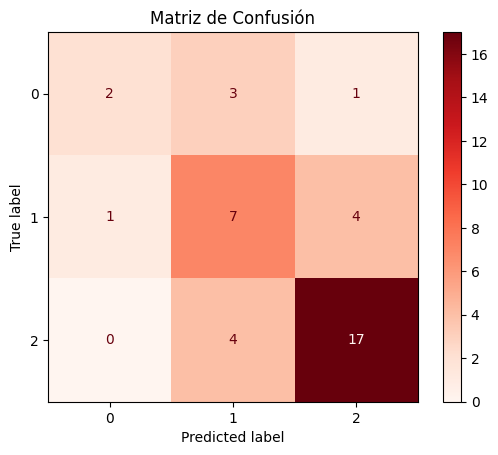

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    grid,
    X_test,
    y_test,
    cmap="Reds"
)

plt.title("Matriz de Confusión")
plt.show()

### Sin weights con SMOTE

In [47]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ("smote", SMOTE(random_state=42)),
    ('model', XGBClassifier(
    objective='multi:softprob',
    num_class=3,

    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
    ))
])

In [48]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],

    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],

    "model__min_child_weight": [1, 3],
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',   # o accuracy
    n_jobs=-1,
    verbose=2
)

grid.fit(
    X_train,
    y_train,
)

print("Best CV F1 Macro:", grid.best_score_)



Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best CV F1 Macro: 0.6600061560689297


In [49]:
# Predicciones
y_pred = grid.predict(X_test)

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("F1 Macro:", f1)

# Reporte completo
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.5384615384615384
F1 Macro: 0.47800224466891134

Classification Report:

              precision    recall  f1-score   support

           0       0.40      0.33      0.36         6
           1       0.33      0.42      0.37        12
           2       0.74      0.67      0.70        21

    accuracy                           0.54        39
   macro avg       0.49      0.47      0.48        39
weighted avg       0.56      0.54      0.55        39


Confusion Matrix:

[[ 2  3  1]
 [ 3  5  4]
 [ 0  7 14]]


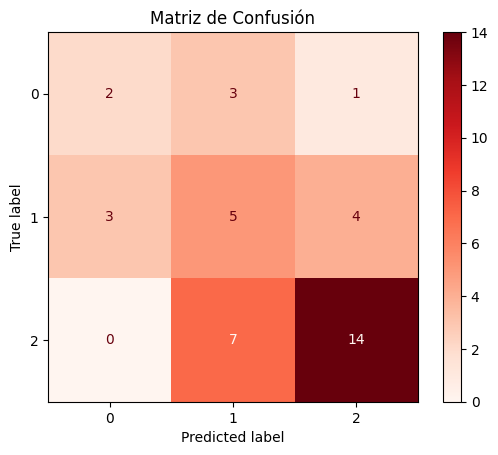

In [50]:
ConfusionMatrixDisplay.from_estimator(
    grid,
    X_test,
    y_test,
    cmap="Reds"
)

plt.title("Matriz de Confusión")
plt.show()

### Sin weights y sin SMOTE

In [51]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
    objective='multi:softprob',
    num_class=3,

    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
    ))
])

In [52]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 4, 6],
    "model__learning_rate": [0.01, 0.05, 0.1],

    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],

    "model__min_child_weight": [1, 3],
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',   
    n_jobs=-1,
    verbose=2
)

grid.fit(
    X_train,
    y_train,
)

print("Best CV F1 Macro:", grid.best_score_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best CV F1 Macro: 0.6770590726627879


In [53]:
# Predicciones
y_pred = grid.predict(X_test)

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("F1 Macro:", f1)

# Reporte completo
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.6410256410256411
F1 Macro: 0.5663354411321891

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.33      0.40         6
           1       0.47      0.58      0.52        12
           2       0.80      0.76      0.78        21

    accuracy                           0.64        39
   macro avg       0.59      0.56      0.57        39
weighted avg       0.65      0.64      0.64        39


Confusion Matrix:

[[ 2  3  1]
 [ 2  7  3]
 [ 0  5 16]]


## Random Forest

### Con weights

In [54]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ))
])

In [55]:
# Hiperparámetros Random Forest

# Grid Search - Random Forest Classifier con Pipeline
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 6, 8, 10],
    'model__min_samples_leaf': [3, 5, 10],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train, model__sample_weight=weights_train)

print("Best CV F1 Macro:", grid_search.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV F1 Macro: 0.6863137130115059


In [56]:
# Predicciones con el mejor modelo
y_pred = grid_search.predict(X_test)

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("F1 Macro:", f1)

# Reporte completo
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.6410256410256411
F1 Macro: 0.5353535353535354

Classification Report:

              precision    recall  f1-score   support

           0       0.33      0.33      0.33         6
           1       0.50      0.42      0.45        12
           2       0.78      0.86      0.82        21

    accuracy                           0.64        39
   macro avg       0.54      0.54      0.54        39
weighted avg       0.63      0.64      0.63        39


Confusion Matrix:

[[ 2  2  2]
 [ 4  5  3]
 [ 0  3 18]]


In [57]:
results = pd.DataFrame(grid_search.cv_results_)

results[
    [
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
        "params"
    ]
].sort_values("rank_test_score").head(10)

,mean_test_score,std_test_score,rank_test_score,params
12,0.686314,0.059355,1,"{'model__max_depth': 6, 'model__min_samples_le..."
21,0.686243,0.054586,2,"{'model__max_depth': 8, 'model__min_samples_le..."
30,0.686243,0.054586,2,"{'model__max_depth': 10, 'model__min_samples_l..."
3,0.678855,0.083154,4,"{'model__max_depth': 4, 'model__min_samples_le..."
9,0.667735,0.062587,5,"{'model__max_depth': 6, 'model__min_samples_le..."
4,0.662611,0.062656,6,"{'model__max_depth': 4, 'model__min_samples_le..."
32,0.652144,0.055392,7,"{'model__max_depth': 10, 'model__min_samples_l..."
31,0.652144,0.055392,7,"{'model__max_depth': 10, 'model__min_samples_l..."
22,0.652144,0.055392,7,"{'model__max_depth': 8, 'model__min_samples_le..."
23,0.652144,0.055392,7,"{'model__max_depth': 8, 'model__min_samples_le..."


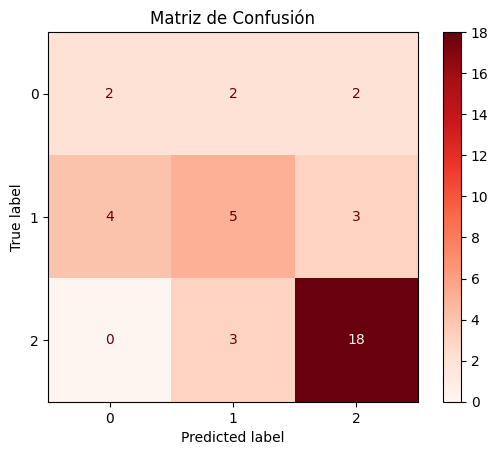

In [58]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    grid_search,
    X_test,
    y_test,
    cmap="Reds"
)

plt.title("Matriz de Confusión")
plt.show()

### Sin weights con SMOTE

In [59]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ("smote", SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 6, 8, 10],
    'model__min_samples_leaf': [3, 5, 10],
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best CV F1 Macro:", grid_search.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV F1 Macro: 0.6919448757019915


In [61]:
# Predicciones con el mejor modelo
y_pred = grid_search.predict(X_test)

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("F1 Macro:", f1)

# Reporte completo
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.6666666666666666
F1 Macro: 0.631957473420888

Classification Report:

              precision    recall  f1-score   support

           0       0.57      0.67      0.62         6
           1       0.50      0.50      0.50        12
           2       0.80      0.76      0.78        21

    accuracy                           0.67        39
   macro avg       0.62      0.64      0.63        39
weighted avg       0.67      0.67      0.67        39


Confusion Matrix:

[[ 4  1  1]
 [ 3  6  3]
 [ 0  5 16]]


In [62]:
results = pd.DataFrame(grid_search.cv_results_)

results[
    [
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
        "params"
    ]
].sort_values("rank_test_score").head(10)

,mean_test_score,std_test_score,rank_test_score,params
25,0.691945,0.087018,1,"{'model__max_depth': 8, 'model__min_samples_le..."
34,0.691945,0.087018,1,"{'model__max_depth': 10, 'model__min_samples_l..."
16,0.691945,0.087018,1,"{'model__max_depth': 6, 'model__min_samples_le..."
7,0.684002,0.091159,4,"{'model__max_depth': 4, 'model__min_samples_le..."
6,0.674665,0.094782,5,"{'model__max_depth': 4, 'model__min_samples_le..."
33,0.669463,0.082617,6,"{'model__max_depth': 10, 'model__min_samples_l..."
24,0.669463,0.082617,6,"{'model__max_depth': 8, 'model__min_samples_le..."
15,0.669463,0.082617,6,"{'model__max_depth': 6, 'model__min_samples_le..."
8,0.666734,0.094682,9,"{'model__max_depth': 4, 'model__min_samples_le..."
17,0.665934,0.097970,10,"{'model__max_depth': 6, 'model__min_samples_le..."


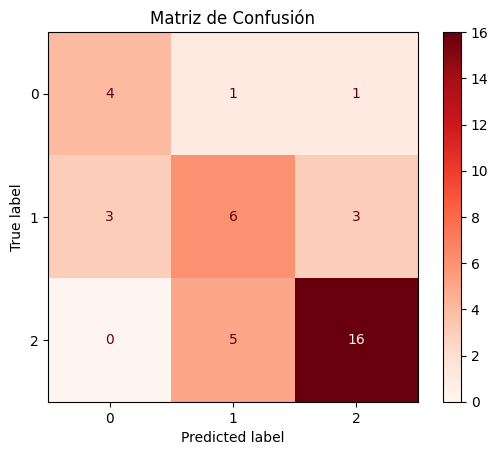

In [63]:
ConfusionMatrixDisplay.from_estimator(
    grid_search,
    X_test,
    y_test,
    cmap="Reds"
)

plt.title("Matriz de Confusión")
plt.show()

### Sin weights y sin SMOTE

In [64]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,
        random_state=42
    ))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 6, 8, 10],
    'model__min_samples_leaf': [3, 5, 10],
}

modelo_final = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

modelo_final.fit(X_train, y_train)

print("Best CV F1 Macro:", modelo_final.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best CV F1 Macro: 0.6480883235632062


In [65]:
# Predicciones con el mejor modelo
y_pred = grid_search.predict(X_test)

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print("Accuracy:", accuracy)
print("F1 Macro:", f1)

# Reporte completo
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.6666666666666666
F1 Macro: 0.631957473420888

Classification Report:

              precision    recall  f1-score   support

           0       0.57      0.67      0.62         6
           1       0.50      0.50      0.50        12
           2       0.80      0.76      0.78        21

    accuracy                           0.67        39
   macro avg       0.62      0.64      0.63        39
weighted avg       0.67      0.67      0.67        39


Confusion Matrix:

[[ 4  1  1]
 [ 3  6  3]
 [ 0  5 16]]


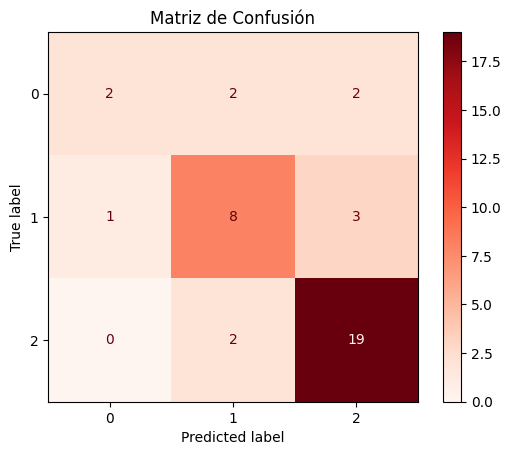

In [72]:
ConfusionMatrixDisplay.from_estimator(
    modelo_final,
    X_test,
    y_test,
    cmap="Reds"
)

plt.title("Matriz de Confusión")
plt.show()

In [79]:
import joblib 
modelo_ganador = modelo_final.best_estimator_
joblib.dump(modelo_ganador, 'modelo_final.joblib')

['modelo_final.joblib']

In [ ]:
# ── Tabla comparativa de modelos ─────────────────────────────────────

resultados = pd.DataFrame([
    # ── Baselines (sin GridSearch) ──────────────────────────────────
    {
        "Modelo": "Logistic Regression",
        "Balanceo": "class_weight + weights",
        "Accuracy": 0.59,  
        "F1 Macro": 0.45,  
        "F1 CV (mean)": 0.61  
    },
    {
        "Modelo": "Random Forest",
        "Balanceo": "weights",
        "Accuracy": 0.69,  
        "F1 Macro": 0.58,
        "F1 CV (mean)": 0.66
    },
    {
        "Modelo": "XGBoost",
        "Balanceo": "weights",
        "Accuracy": 0.67,  
        "F1 Macro": 0.61,
        "F1 CV (mean)": 0.61
    },
    # ── GridSearch XGBoost ───────────────────────────────────────────
    {
        "Modelo": "XGBoost (GS)",
        "Balanceo": "weights",
        "Accuracy": 0.64,   
        "F1 Macro": 0.56,
        "F1 CV (mean)": 0.67  
    },
    {
        "Modelo": "XGBoost (GS)",
        "Balanceo": "SMOTE",
        "Accuracy": 0.59,
        "F1 Macro": 0.54,
        "F1 CV (mean)": 0.67
    },
    {
        "Modelo": "XGBoost (GS)",
        "Balanceo": "sin balanceo",
        "Accuracy": 0.61,
        "F1 Macro": 0.54,
        "F1 CV (mean)": 0.67
    },
    # ── GridSearch Random Forest ─────────────────────────────────────
    {
        "Modelo": "Random Forest (GS)",
        "Balanceo": "weights",
        "Accuracy": 0.64,  
        "F1 Macro": 0.54,
        "F1 CV (mean)": 0.69 
    },
    {
        "Modelo": "Random Forest (GS)",
        "Balanceo": "SMOTE",
        "Accuracy": 0.67,
        "F1 Macro": 0.63,
        "F1 CV (mean)": 0.69
    },
    {
        "Modelo": "Random Forest (GS)",
        "Balanceo": "sin balanceo",
        "Accuracy": 0.74,
        "F1 Macro": 0.65,
        "F1 CV (mean)": 0.65
    },
])

# Ordenar por F1 Macro descendente y resaltar el mejor
resultados = resultados.sort_values("F1 Macro", ascending=False).reset_index(drop=True)

resultados.style \
    .format({"Accuracy": "{:.2f}", "F1 Macro": "{:.2f}", "F1 CV (mean)": "{:.2f}"}) \
    .highlight_max(subset=["F1 Macro", "Accuracy"], color="#22bb41") \
    .set_caption("Tabla comparativa de modelos — métricas en conjunto de prueba (test_size=0.20)")

,Modelo,Balanceo,Accuracy,F1 Macro,F1 CV (mean)
0,Random Forest (GS),sin balanceo,0.74,0.65,0.65
1,Random Forest (GS),SMOTE,0.67,0.63,0.69
2,XGBoost,weights,0.67,0.61,0.61
3,Random Forest,weights,0.69,0.58,0.66
4,XGBoost (GS),weights,0.64,0.56,0.67
5,XGBoost (GS),SMOTE,0.59,0.54,0.67
6,XGBoost (GS),sin balanceo,0.61,0.54,0.67
7,Random Forest (GS),weights,0.64,0.54,0.69
8,Logistic Regression,class_weight + weights,0.59,0.45,0.61


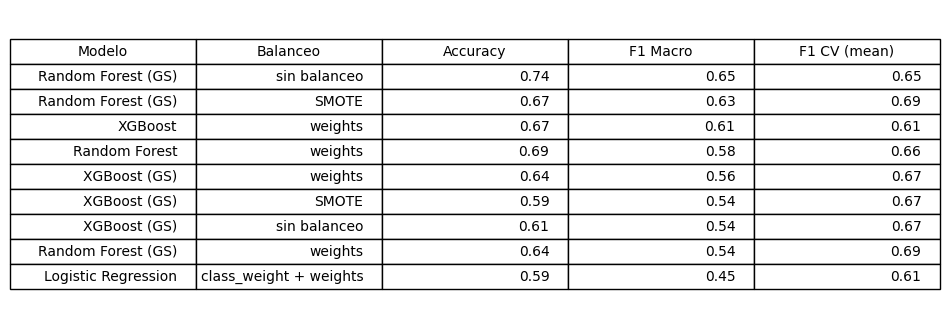

In [78]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

tabla = ax.table(
    cellText=resultados.values,
    colLabels=resultados.columns,
    loc='center'
)

tabla.auto_set_font_size(False)
tabla.set_fontsize(10)
tabla.scale(1.2, 1.5)

plt.savefig("comparativa_modelos.png",
            bbox_inches="tight",
            dpi=300)
plt.show()

# Análisis después del módelo 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Guardamos el modelo
modelo_ganador = modelo_final.best_estimator_

# Predicciones del modelo final en el conjunto de prueba.
y_pred_final = modelo_ganador.predict(X_test)

# Métricas principales.
accuracy_final = accuracy_score(y_test, y_pred_final)
f1_final = f1_score(y_test, y_pred_final, average="macro")

print("Modelo final: Random Forest sin weights y sin SMOTE")
print("Accuracy:", round(accuracy_final, 4))
print("F1 Macro:", round(f1_final, 4))
print("Best CV F1 Macro:", round(modelo_final.best_score_, 4))

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=["Detractor", "Neutro", "Promotor"]
))


rf_model = modelo_final.best_estimator_.named_steps['model']
preprocessor_fit = modelo_final.best_estimator_.named_steps['preprocessor']

num_feature_names = numeric_cols  # ya definidos arriba

ohe = preprocessor_fit.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()

all_feature_names = num_feature_names + cat_feature_names

# ── 3. Importancia global (mean decrease impurity) ──────────
importances_global = rf_model.feature_importances_
feat_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances_global
}).sort_values('importance', ascending=False)

print("Top 10 variables más importantes (global):")
print(feat_df.head(10).to_string(index=False))

Modelo final: Random Forest sin weights y sin SMOTE
Accuracy: 0.7436
F1 Macro: 0.6519
Best CV F1 Macro: 0.6481

Classification Report:

              precision    recall  f1-score   support

   Detractor       0.67      0.33      0.44         6
      Neutro       0.67      0.67      0.67        12
    Promotor       0.79      0.90      0.84        21

    accuracy                           0.74        39
   macro avg       0.71      0.63      0.65        39
weighted avg       0.73      0.74      0.73        39

Top 10 variables más importantes (global):
             feature  importance
satisfaccion_general    0.278488
facilidad_resolucion    0.228436
     atencion_humana    0.074665
             rapidez    0.061797
   facilidad_digital    0.057564
       transparencia    0.053763
           confianza    0.047339
         n_productos    0.038594
 estabilidad_digital    0.036016
      antiguedad_num    0.034634


In [ ]:
from sklearn.inspection import permutation_importance

# Necesitamos X_test sin la columna 'peso'
X_test_clean = X_test.drop(columns=['peso'], errors='ignore')

result = permutation_importance(
    modelo_final.best_estimator_,
    X_test_clean,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring='f1_macro'   # métrica base
)

perm_df = pd.DataFrame({
    'feature': X_test_clean.columns,
    'importance_mean': result.importances_mean,
    'importance_std':  result.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nImportancia por permutación (global, top 10):")
print(perm_df.head(10).to_string(index=False))


Importancia por permutación (global, top 10):
             feature  importance_mean  importance_std
satisfaccion_general         0.244448        0.035371
facilidad_resolucion         0.129523        0.041330
             rapidez         0.081547        0.030740
      antiguedad_num         0.074377        0.051570
               banco         0.038277        0.046889
           confianza         0.031962        0.020376
 estabilidad_digital         0.030051        0.018412
         n_productos         0.023064        0.019697
     atencion_humana         0.019476        0.031323
       transparencia         0.013418        0.010310


In [69]:
# ── 5. Promedios por clase de las variables originales (Likert) ──
# Esto complementa el RF: muestra en qué dirección apunta cada variable

CLASES = {0: 'Detractor', 1: 'Neutro', 2: 'Promotor'}
VARS_ANALISIS = [
    'satisfaccion_general', 'confianza', 'facilidad_resolucion',
    'transparencia', 'rapidez', 'atencion_humana',
    'facilidad_digital', 'estabilidad_digital'
]

profile_df = (
    df_model
    .groupby('nps_label')[VARS_ANALISIS]
    .mean()
    .rename(index=CLASES)
    .round(2)
)

print("\nPerfil promedio por segmento NPS (escala 1-5):")
print(profile_df.T.to_string())


Perfil promedio por segmento NPS (escala 1-5):
nps_label             Detractor  Neutro  Promotor
satisfaccion_general       2.74    3.87      4.65
confianza                  3.37    4.07      4.44
facilidad_resolucion       2.67    3.46      4.48
transparencia              2.74    3.49      4.16
rapidez                    2.70    3.69      4.29
atencion_humana            3.00    3.70      4.35
facilidad_digital          2.89    3.44      4.18
estabilidad_digital        3.15    3.57      4.23


## Desempeño por categoría

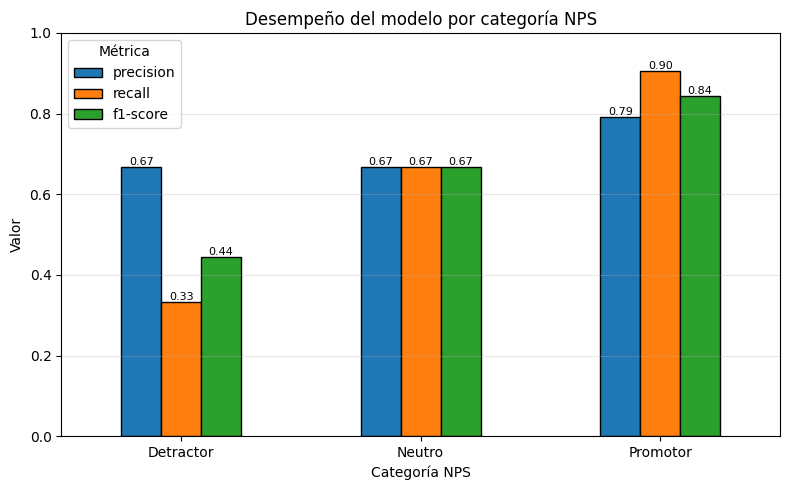

,precision,recall,f1-score
Detractor,0.667,0.333,0.444
Neutro,0.667,0.667,0.667
Promotor,0.792,0.905,0.844


In [74]:
report = classification_report(
    y_test,
    y_pred_final,
    target_names=["Detractor", "Neutro", "Promotor"],
    output_dict=True
)

metricas_clase = pd.DataFrame(report).T.loc[
    ["Detractor", "Neutro", "Promotor"],
    ["precision", "recall", "f1-score"]
]

ax = metricas_clase.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

plt.title("Desempeño del modelo por categoría NPS")
plt.ylabel("Valor")
plt.xlabel("Categoría NPS")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.grid(axis="y", alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8)

plt.tight_layout()
plt.show()

metricas_clase.round(3)

## Permutación

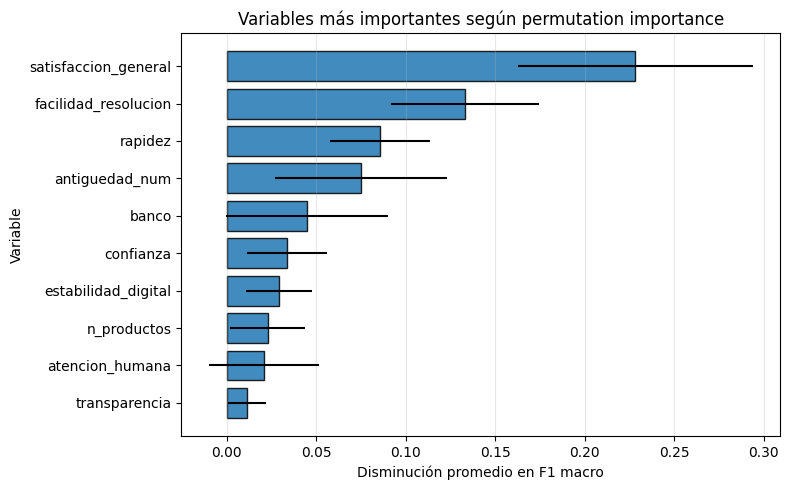

,feature,importance_mean,importance_std
7,satisfaccion_general,0.2283,0.0655
6,facilidad_resolucion,0.1329,0.0414
0,rapidez,0.0854,0.0279
9,antiguedad_num,0.0752,0.0481
8,banco,0.0448,0.0452
4,confianza,0.0336,0.0223
3,estabilidad_digital,0.0290,0.0185
11,n_productos,0.0228,0.0209
5,atencion_humana,0.0207,0.0309
1,transparencia,0.0112,0.0104


In [ ]:
result = permutation_importance(
    modelo_ganador,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values("importance_mean", ascending=False)

top_perm = perm_df.head(10).sort_values("importance_mean")

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    top_perm["feature"],
    top_perm["importance_mean"],
    xerr=top_perm["importance_std"],
    edgecolor="black",
    alpha=0.85
)

ax.set_title("Variables más importantes según permutation importance")
ax.set_xlabel("Disminución promedio en F1 macro")
ax.set_ylabel("Variable")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

perm_df.head(10).round(4)

## Heatmap 

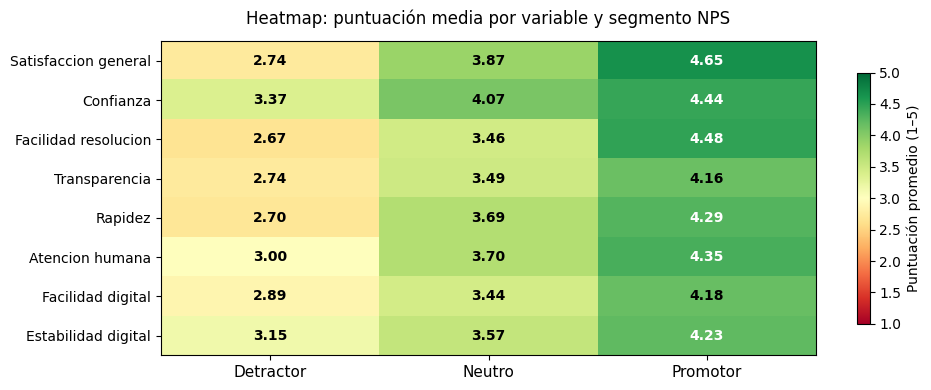

In [71]:
# ── 7. Heatmap de diferencias entre clases ──────────────────
fig, ax = plt.subplots(figsize=(10, 4))

# Matriz: filas = variables, columnas = clases
heatmap_data = profile_df[VARS_ANALISIS].T  # shape: (8 vars x 3 clases)

im = ax.imshow(heatmap_data.values, cmap='RdYlGn', aspect='auto',
               vmin=1, vmax=5)

ax.set_xticks(range(3))
ax.set_xticklabels(heatmap_data.columns, fontsize=11)
ax.set_yticks(range(len(VARS_ANALISIS)))
ax.set_yticklabels([v.replace('_', ' ').capitalize() for v in VARS_ANALISIS], fontsize=10)
ax.set_title('Heatmap: puntuación media por variable y segmento NPS', fontsize=12, pad=12)

# Anotar valores en cada celda
for i in range(len(VARS_ANALISIS)):
    for j in range(3):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='white' if val < 2.2 or val > 4.2 else 'black')

plt.colorbar(im, ax=ax, label='Puntuación promedio (1–5)', shrink=0.8)
plt.tight_layout()
plt.show()